In [ ]:
import kagglehub
import os
import shutil
import pandas as pd
import cv2
from pathlib import Path
import yaml


In [ ]:
#(Dental Radiography)
path_ds1 = kagglehub.dataset_download("imtkaggleteam/dental-radiography")
base_ds1 = Path(path_ds1) / "dental_radiography"

#(Dental OPG)
path_ds2 = kagglehub.dataset_download("imtkaggleteam/dental-opg-xray-dataset")
base_ds2 = Path(path_ds2) / "Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset"

print(f"DS1 path: {base_ds1}")
print(f"DS2 path: {base_ds2}")


Using Colab cache for faster access to the 'dental-opg-xray-dataset' dataset.
DS1 path: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/dental_radiography
DS2 path: /kaggle/input/dental-opg-xray-dataset/Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset


In [ ]:

DS1_MAP = {
    'Cavity': 0,
    'Impacted Tooth': 1,
    'Fillings': None,
    'Implant': None,
    '__background__': None
}

DS2_MAP = {
    0: None, # Healthy
    1: 0,    # Caries -> Caries
    2: 1,    # Impacted -> Impacted
    3: 2,    # Broken -> Fracture
    4: None, # Infection (ігноруємо)
    5: 2     # Fractured -> Fracture
}

In [ ]:
!pip install -q kagglehub opencv-python pandas

import kagglehub
import shutil
import pandas as pd
import cv2
import os
from pathlib import Path

#1. Підготовка шляхів (щоб уникнути FileNotFoundError)
path_ds1_dl = kagglehub.dataset_download("imtkaggleteam/dental-radiography")
path_ds2_dl = kagglehub.dataset_download("imtkaggleteam/dental-opg-xray-dataset")

# Автоматичний пошук кореневих папок
try:
    base_ds1 = list(Path(path_ds1_dl).rglob('_annotations.csv'))[0].parent.parent
    base_ds2 = list(Path(path_ds2_dl).rglob('Augmented Dataset'))[0]
except IndexError:
    # Запасний варіант, якщо структура відрізняється
    base_ds1 = Path(path_ds1_dl) / "dental_radiography"
    base_ds2 = Path(path_ds2_dl) / "Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset"

# 2. Налаштування 
DS1_MAP = {'Cavity': 0, 'Impacted Tooth': 1, 'Fillings': None, 'Implant': None, '__background__': None}
DS2_MAP = {0: None, 1: 0, 2: 1, 3: 2, 4: None, 5: 2}
ID_TO_NAME = {0: 'Caries', 1: 'Impacted', 2: 'Fracture'}

#3. Функція генерації 
def create_standard_dataset(output_path):
    output_path = Path(output_path)

    if output_path.exists():
        shutil.rmtree(output_path)

    for split in ['train', 'valid']:
        (output_path / split).mkdir(parents=True, exist_ok=True)

    for split in ['train', 'valid']:
        new_rows = []

        # Processing Dataset 1
        csv_file = base_ds1 / split / '_annotations.csv'
        if csv_file.exists():
            df = pd.read_csv(csv_file)
            for _, row in df.iterrows():
                if row['class'] in DS1_MAP and DS1_MAP[row['class']] is not None:
                    cls_id = DS1_MAP[row['class']]
                    new_filename = f"ds1_{row['filename']}"

                    src_img = base_ds1 / split / row['filename']
                    dst_img = output_path / split / new_filename

                    if src_img.exists():
                        if not dst_img.exists():
                            shutil.copy(src_img, dst_img)

                        new_rows.append({
                            'filename': new_filename,
                            'width': row['width'], 'height': row['height'],
                            'class': ID_TO_NAME[cls_id],
                            'xmin': row['xmin'], 'ymin': row['ymin'],
                            'xmax': row['xmax'], 'ymax': row['ymax']
                        })

        # Processing Dataset 2
        ds2_splits = ['train'] if split == 'train' else ['valid', 'test']
        for ds2_split in ds2_splits:
            img_dir = base_ds2 / ds2_split / 'images'
            lbl_dir = base_ds2 / ds2_split / 'labels'

            if img_dir.exists():
                for img_file in img_dir.glob('*.*'):
                    txt_file = lbl_dir / f"{img_file.stem}.txt"
                    if txt_file.exists():
                        img = cv2.imread(str(img_file))
                        if img is None: continue
                        h, w = img.shape[:2]

                        with open(txt_file, 'r') as f:
                            lines = f.readlines()

                        valid_obj = False
                        temp_objs = []
                        for line in lines:
                            parts = line.strip().split()
                            orig_id = int(parts[0])

                            if orig_id in DS2_MAP and DS2_MAP[orig_id] is not None:
                                new_id = DS2_MAP[orig_id]
                                x_c, y_c, bw, bh = map(float, parts[1:])

                                xmin = int((x_c - bw / 2) * w)
                                ymin = int((y_c - bh / 2) * h)
                                xmax = int((x_c + bw / 2) * w)
                                ymax = int((y_c + bh / 2) * h)

                                temp_objs.append({
                                    'filename': f"ds2_{img_file.name}",
                                    'width': w, 'height': h,
                                    'class': ID_TO_NAME[new_id],
                                    'xmin': max(0, xmin), 'ymin': max(0, ymin),
                                    'xmax': min(w, xmax), 'ymax': min(h, ymax)
                                })
                                valid_obj = True

                        if valid_obj:
                            dst_img = output_path / split / f"ds2_{img_file.name}"
                            if not dst_img.exists():
                                shutil.copy(img_file, dst_img)
                            new_rows.extend(temp_objs)

        if new_rows:
            df_out = pd.DataFrame(new_rows)

            cols = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
            df_out = df_out[cols]
            df_out.to_csv(output_path / split / '_annotations.csv', index=False)


create_standard_dataset("/content/dataset_standard")
print('+++++++++++ DONE +++++++++++')

Using Colab cache for faster access to the 'dental-radiography' dataset.


100%|██████████| 197M/197M [00:09<00:00, 21.0MB/s]

Extracting files...


+++++++++++ DONE +++++++++++


# **Модель**

Імпорт бібліотек та Конфігурація

In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd
import cv2
import numpy as np
import time
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

DATA_DIR = Path("/content/dataset_standard")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"

CLASSES = ['__background__', 'Caries', 'Impacted', 'Fracture']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

Клас Dataset та Утиліти

In [ ]:
class DentalDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.csv_path = root_dir / "_annotations.csv"

        if not self.csv_path.exists():
            raise FileNotFoundError(f"CSV not found: {self.csv_path}")

        self.df = pd.read_csv(self.csv_path)
        self.imgs = self.df['filename'].unique()

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = str(self.root_dir / img_name)

        image = cv2.imread(img_path)
        if image is None:
            return self.__getitem__((idx + 1) % len(self))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)
        image /= 255.0

        records = self.df[self.df['filename'] == img_name]
        boxes = []
        labels = []

        for _, row in records.iterrows():
            if row['class'] in CLASS_TO_IDX:
                if row['xmax'] > row['xmin'] and row['ymax'] > row['ymin']:
                    boxes.append([row['xmin'], row['ymin'], row['xmax'], row['ymax']])
                    labels.append(CLASS_TO_IDX[row['class']])

        if self.transforms:
            if len(boxes) > 0:
                transformed = self.transforms(image=image, bboxes=boxes, labels=labels)
                image = transformed['image']
                boxes = transformed['bboxes']
                labels = transformed['labels']
            else:
                plain_transform = A.Compose([ToTensorV2()])
                transformed = plain_transform(image=image)
                image = transformed['image']

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).permute(2, 0, 1)

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.tensor([0.]),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64)
        }

        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

Трансформації (Аугментація)

In [ ]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.1))

def get_valid_transforms():
    return A.Compose([
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

Підготовка DataLoader та Sampler

In [ ]:
train_dataset = DentalDataset(TRAIN_DIR, transforms=get_train_transforms())
valid_dataset = DentalDataset(VALID_DIR, transforms=get_valid_transforms())

df = train_dataset.df
class_counts = df['class'].value_counts()
weights_per_class = {cls: (1.0 / count) for cls, count in class_counts.items() if count > 0}
img_weights = []

for img_name in train_dataset.imgs:
    labels = df[df['filename'] == img_name]['class'].values
    if len(labels) > 0:
        w = max([weights_per_class.get(l, 0) for l in labels if l in weights_per_class])
    else:
        w = 0
    img_weights.append(w)

sampler = WeightedRandomSampler(torch.DoubleTensor(img_weights), len(img_weights))

train_loader = DataLoader(train_dataset, batch_size=4, sampler=sampler, num_workers=2, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Ініціалізація Моделі

In [ ]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Цикл Навчання

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for images, targets in train_loader:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    lr_scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Time: {time.time()-start_time:.0f}s")

torch.save(model.state_dict(), "fasterrcnn_resnet50_dental.pth")

Epoch 1/20 | Loss: 0.6701 | Time: 130s
Epoch 2/20 | Loss: 0.5529 | Time: 129s
Epoch 3/20 | Loss: 0.5067 | Time: 129s
Epoch 4/20 | Loss: 0.4540 | Time: 129s
Epoch 5/20 | Loss: 0.4468 | Time: 129s
Epoch 6/20 | Loss: 0.4351 | Time: 129s
Epoch 7/20 | Loss: 0.4285 | Time: 130s
Epoch 8/20 | Loss: 0.4386 | Time: 129s
Epoch 9/20 | Loss: 0.4251 | Time: 128s
Epoch 10/20 | Loss: 0.4210 | Time: 128s
Epoch 11/20 | Loss: 0.4392 | Time: 129s
Epoch 12/20 | Loss: 0.4304 | Time: 128s
Epoch 13/20 | Loss: 0.4212 | Time: 128s
Epoch 14/20 | Loss: 0.4274 | Time: 129s
Epoch 15/20 | Loss: 0.4227 | Time: 128s
Epoch 16/20 | Loss: 0.4325 | Time: 129s
Epoch 17/20 | Loss: 0.4295 | Time: 130s
Epoch 18/20 | Loss: 0.4314 | Time: 128s
Epoch 19/20 | Loss: 0.4372 | Time: 129s
Epoch 20/20 | Loss: 0.4181 | Time: 128s


# **Аналіз**

Розрахунок стандартних метрик

In [ ]:
!pip install -q torchmetrics
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

def evaluate_model(model, data_loader, device):
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    model.eval()
    model.to(device)

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = list(img.to(device) for img in images)
            preds = model(images)

            formatted_preds = []
            for p in preds:
                formatted_preds.append({
                    "boxes": p["boxes"],
                    "scores": p["scores"],
                    "labels": p["labels"]
                })

            formatted_targets = []
            for t in targets:
                formatted_targets.append({
                    "boxes": t["boxes"].to(device),
                    "labels": t["labels"].to(device)
                })

            metric.update(formatted_preds, formatted_targets)

    return metric.compute()

metrics = evaluate_model(model, valid_loader, DEVICE)

print("\n" + "="*40)
print("РЕЗУЛЬТАТИ ТЕСТУВАННЯ (Validation Set)")
print("="*40)
print(f"mAP (General):       {metrics['map']:.4f}")
print(f"mAP@50 (Standard):   {metrics['map_50']:.4f}")
print(f"mAP@75 (Strict):     {metrics['map_75']:.4f}")
print("-" * 40)
print("ТОЧНІСТЬ ПО КЛАСАХ (mAP per Class):")

if 'map_per_class' in metrics:
    per_class = metrics['map_per_class']
    target_classes = [1, 2, 3]

    for i, score in enumerate(per_class):
        try:
            cls_name = CLASSES[target_classes[i]]
        except:
            cls_name = f"Class {i}"
        print(f"  • {cls_name:<15}: {score:.4f}")
else:
    print("Не вдалося розрахувати по класах.")
print("="*40)

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]


РЕЗУЛЬТАТИ ТЕСТУВАННЯ (Validation Set)
mAP (General):       0.2732
mAP@50 (Standard):   0.5091
mAP@75 (Strict):     0.2639
----------------------------------------
ТОЧНІСТЬ ПО КЛАСАХ (mAP per Class):
  • Caries         : 0.2205
  • Impacted       : 0.5010
  • Fracture       : 0.0982


Функція для детальної статистики та матриці плутанини

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.ops import box_iou

def get_confusion_matrix_and_stats(model, loader, device, num_classes, conf_threshold=0.5, iou_threshold=0.5):
    model.eval()

    cm = np.zeros((num_classes, num_classes), dtype=int)
    stats = {i: {'TP': 0, 'FP': 0, 'FN': 0} for i in range(1, num_classes)}

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Аналіз"):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for i, output in enumerate(outputs):
                target = targets[i]
                gt_boxes = target['boxes'].to(device)
                gt_labels = target['labels'].to(device)

                pred_boxes = output['boxes']
                pred_scores = output['scores']
                pred_labels = output['labels']

                keep = pred_scores >= conf_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                    continue

                if len(gt_boxes) == 0:
                    for p_label in pred_labels:
                        cm[0, p_label] += 1
                        if p_label.item() in stats: stats[p_label.item()]['FP'] += 1
                    continue

                if len(pred_boxes) == 0:
                    for g_label in gt_labels:
                        cm[g_label, 0] += 1
                        if g_label.item() in stats: stats[g_label.item()]['FN'] += 1
                    continue

                ious = box_iou(gt_boxes, pred_boxes)
                gt_matched = set()
                pred_matched = set()

                for g_idx in range(len(gt_boxes)):
                    max_iou, p_idx = torch.max(ious[g_idx], dim=0)
                    p_idx = p_idx.item()

                    if max_iou >= iou_threshold:
                        gt_label = gt_labels[g_idx].item()
                        pred_label = pred_labels[p_idx].item()

                        if p_idx not in pred_matched:
                            cm[gt_label, pred_label] += 1
                            if gt_label == pred_label:
                                if gt_label in stats: stats[gt_label]['TP'] += 1
                            else:
                                if gt_label in stats: stats[gt_label]['FN'] += 1
                                if pred_label in stats: stats[pred_label]['FP'] += 1

                            gt_matched.add(g_idx)
                            pred_matched.add(p_idx)

                for g_idx in range(len(gt_boxes)):
                    if g_idx not in gt_matched:
                        gt_label = gt_labels[g_idx].item()
                        cm[gt_label, 0] += 1
                        if gt_label in stats: stats[gt_label]['FN'] += 1

                for p_idx in range(len(pred_boxes)):
                    if p_idx not in pred_matched:
                        pred_label = pred_labels[p_idx].item()
                        cm[0, pred_label] += 1
                        if pred_label in stats: stats[pred_label]['FP'] += 1

    return cm, stats

Вивід таблиць

In [ ]:
cm, stats = get_confusion_matrix_and_stats(model, valid_loader, DEVICE, len(CLASSES), conf_threshold=0.5, iou_threshold=0.5)

print("\n" + "="*60)
print(f"{'CLASS':<15} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10} | {'SUPPORT':<10}")
print("-" * 60)

avg_prec, avg_rec, avg_f1 = 0, 0, 0
count = 0

for cls_id, data in stats.items():
    tp = data['TP']
    fp = data['FP']
    fn = data['FN']
    total_gt = tp + fn

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    cls_name = CLASSES[cls_id]
    print(f"{cls_name:<15} | {precision:.4f}     | {recall:.4f}     | {f1:.4f}     | {total_gt:<10}")

    avg_prec += precision
    avg_rec += recall
    avg_f1 += f1
    count += 1

print("-" * 60)
print(f"{'AVERAGE':<15} | {avg_prec/count:.4f}     | {avg_rec/count:.4f}     | {avg_f1/count:.4f}     | -")
print("="*60 + "\n")

Аналіз:   0%|          | 0/23 [00:00<?, ?it/s]


CLASS           | PRECISION  | RECALL     | F1-SCORE   | SUPPORT   
------------------------------------------------------------
Caries          | 0.2959     | 0.5577     | 0.3867     | 52        
Impacted        | 0.6392     | 0.9118     | 0.7515     | 68        
Fracture        | 0.2034     | 0.6694     | 0.3120     | 124       
------------------------------------------------------------
AVERAGE         | 0.3795     | 0.7129     | 0.4834     | -



Матриця плутанини

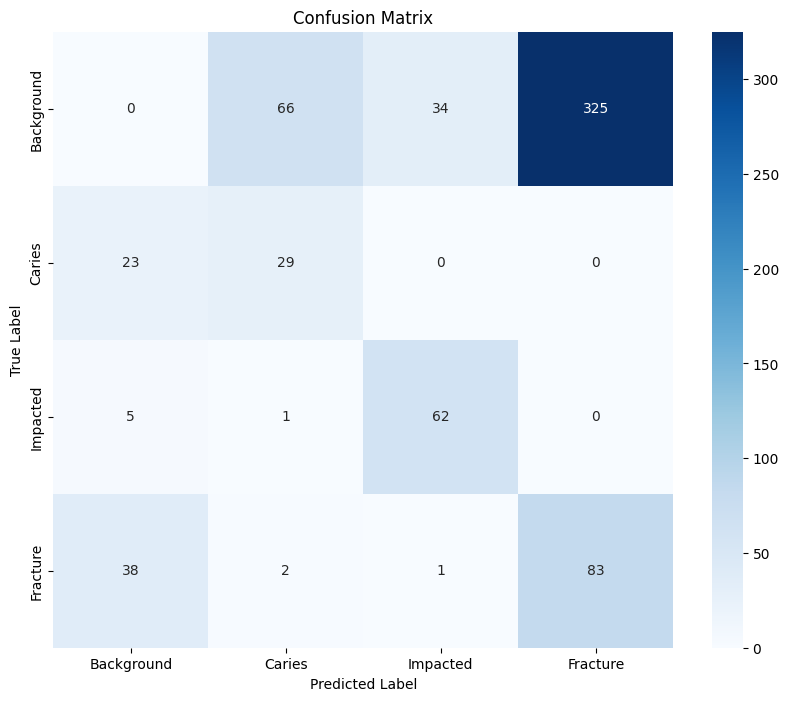

In [ ]:
plt.figure(figsize=(10, 8))
labels = ["Background"] + CLASSES[1:]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Вигляд рамок

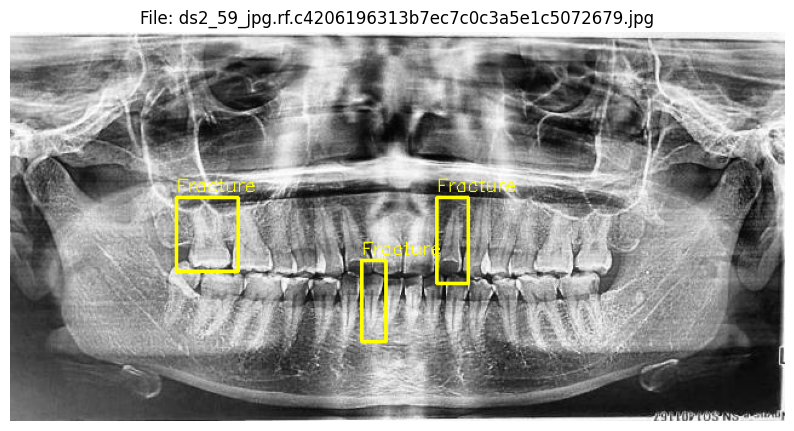

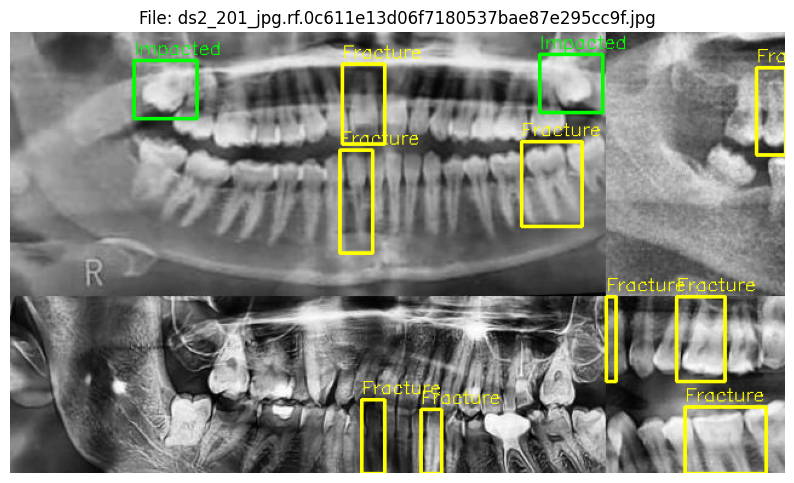

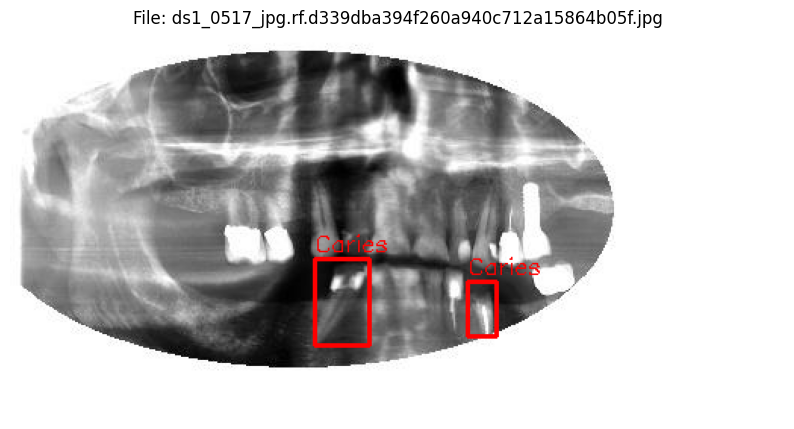

In [ ]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

# Конфігурація шляхів
TRAIN_DIR = Path("/content/dataset_standard/train")
CSV_PATH = TRAIN_DIR / "_annotations.csv"

# Кольори класів (RGB)
CLASS_COLORS = {
    'Caries': (255, 0, 0),     # Червоний
    'Impacted': (0, 255, 0),   # Зелений
    'Fracture': (255, 255, 0)  # Жовтий
}

def visualize_ground_truth(num_samples=3):
    if not CSV_PATH.exists():
        return

    df = pd.read_csv(CSV_PATH)
    unique_files = df['filename'].unique()

    if len(unique_files) == 0:
        return

    # Вибір випадкових файлів
    selected_files = random.sample(list(unique_files), min(num_samples, len(unique_files)))

    for filename in selected_files:
        img_path = TRAIN_DIR / filename

        img = cv2.imread(str(img_path))
        if img is None: continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Отримання анотацій для конкретного файлу
        annotations = df[df['filename'] == filename]

        for _, row in annotations.iterrows():
            cls = row['class']
            x1, y1, x2, y2 = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
            color = CLASS_COLORS.get(cls, (255, 255, 255))

            # Малювання рамки та підпису
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, cls, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        # Відображення
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"File: {filename}")
        plt.show()

visualize_ground_truth(3)